# Practical 256-node scale sweep

This notebook uses a small successive-halving search to select parameters before committing to a full-scale training run. It keeps graph size fixed at 256 because smaller graphs do not preserve the hub tail being optimized.

The search has three fidelities:

| Stage | Candidates | Training graphs | Maximum epochs | Evaluation graphs |
|---|---:|---:|---:|---:|
| 1 | 12 | 8,192 | 20 | 256 |
| 2 | 4 | 32,768 | 50 | 512 |
| 3 | 2 | 65,536 | 90 | 1,024 |

Each promoted configuration is retrained from scratch. Every completed trial is saved immediately as JSON and a model checkpoint, so the notebook can resume after interruption. It retains histories and metrics instead of GPU models.


In [1]:
import gc
import itertools
import json
from dataclasses import asdict, replace
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import torch

from svae import ARTIFACTS_DIR, PROFILES, SeededPAGenerator, train
from svae.evaluate import (
    ba_sequence_likelihood_experiment,
    degree_distribution_experiment,
    graph_statistics_experiment,
)
from svae.simulate import parents_to_graph
from svae.train import make_data_splits


## Candidate space

The sweep excludes `beta=4`, which the earlier pilot showed was too restrictive. It searches three learning rates, three beta values, and three capacity levels. Twelve of the 27 combinations are sampled with a fixed seed, with the current reference configuration included explicitly.

This is broad enough to detect useful interactions without paying for a full Cartesian grid.


In [2]:
SEARCH_SEED = 20260922
ARTIFACT_ROOT = ARTIFACTS_DIR / "scale-sweep"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

learning_rates = (1e-4, 3e-4, 1e-3)
betas = (0.5, 1.0, 2.0)
architectures = (
    (512, 128),
    (768, 256),
    (1024, 256),
)

reference_spec = {"lr": 3e-4, "beta": 1.0, "hidden": 512, "latent_dim": 128}
full_pool = [
    {"lr": lr, "beta": beta, "hidden": hidden, "latent_dim": latent}
    for lr, beta, (hidden, latent) in itertools.product(learning_rates, betas, architectures)
]
remaining_pool = [spec for spec in full_pool if spec != reference_spec]
rng = np.random.default_rng(SEARCH_SEED)
candidates = [reference_spec] + [remaining_pool[index] for index in rng.choice(len(remaining_pool), 11, replace=False)]


def candidate_name(spec):
    return (
        f"lr_{spec['lr']:g}_beta_{spec['beta']:g}_"
        f"h_{spec['hidden']}_z_{spec['latent_dim']}"
    )

candidate_specs = {candidate_name(spec): spec for spec in candidates}
pprint(candidate_specs, sort_dicts=False)


{'lr_0.0003_beta_1_h_512_z_128': {'lr': 0.0003,
                                  'beta': 1.0,
                                  'hidden': 512,
                                  'latent_dim': 128},
 'lr_0.001_beta_0.5_h_1024_z_256': {'lr': 0.001,
                                    'beta': 0.5,
                                    'hidden': 1024,
                                    'latent_dim': 256},
 'lr_0.0003_beta_2_h_1024_z_256': {'lr': 0.0003,
                                   'beta': 2.0,
                                   'hidden': 1024,
                                   'latent_dim': 256},
 'lr_0.001_beta_2_h_512_z_128': {'lr': 0.001,
                                 'beta': 2.0,
                                 'hidden': 512,
                                 'latent_dim': 128},
 'lr_0.0003_beta_0.5_h_1024_z_256': {'lr': 0.0003,
                                     'beta': 0.5,
                                     'hidden': 1024,
                                     'latent_d

## Promotion measurements

Validation loss alone can favor reconstruction without preserving prior-sampled graph behavior. Each trial therefore generates a small collection and compares it with an equal-size NetworkX reference using:

- validation reconstruction plus KL,
- pooled degree-distribution total variation,
- degree-16-and-above tail-mass error,
- maximum-degree mean error measured in NetworkX standard deviations,
- leaf-fraction mean error measured in NetworkX standard deviations,
- root reinforcement-correlation error,
- Wasserstein distance between normalized BA sequence log likelihoods.

Candidates receive a rank for every measurement; the sum of ranks is the promotion score. Lower is better. Rank aggregation keeps one measurement's numerical scale from dominating the others.


In [3]:
STAGES = (
    {"name": "stage_1", "train_graphs": 8_192, "val_graphs": 2_048, "epochs": 20,
     "eval_graphs": 256, "promote": 4, "patience": 5},
    {"name": "stage_2", "train_graphs": 32_768, "val_graphs": 4_096, "epochs": 50,
     "eval_graphs": 512, "promote": 2, "patience": 8},
    {"name": "stage_3", "train_graphs": 65_536, "val_graphs": 4_096, "epochs": 90,
     "eval_graphs": 1_024, "promote": None, "patience": 12},
)

RANK_METRICS = (
    "val_objective_graph",
    "degree_tv",
    "tail_mass_error",
    "max_degree_error_sd",
    "leaf_fraction_error_sd",
    "reinforcement_error",
    "ba_likelihood_wasserstein",
)


def release_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def evaluate_checkpoint(run, reference_graphs, evaluation_seeds):
    generator = SeededPAGenerator.from_model(run.model)
    vae_graphs = [generator.graph(seed) for seed in evaluation_seeds]
    collections = {"NetworkX": reference_graphs, "VAE": vae_graphs}

    degrees = degree_distribution_experiment(
        collections, tail_thresholds=(16,), show=False
    )
    statistics = graph_statistics_experiment(
        collections, num_nodes=run.config.num_nodes,
        bootstrap_samples=20, show=False,
    )
    likelihood = ba_sequence_likelihood_experiment(
        collections, normalize_per_arrival=True, show=False
    )

    reference_summary = statistics["hub_leaf_summary"]["NetworkX"]
    vae_summary = statistics["hub_leaf_summary"]["VAE"]
    reference_reinforcement = statistics["reinforcement"]["NetworkX"]["pearson"]
    vae_reinforcement = statistics["reinforcement"]["VAE"]["pearson"]
    metrics = {
        "degree_tv": float(degrees["VAE"]["total_variation"]),
        "tail_mass_error": abs(
            float(degrees["VAE"]["tail_mass"][16])
            - float(degrees["NetworkX"]["tail_mass"][16])
        ),
        "max_degree_error_sd": abs(
            float(vae_summary["max_degree_mean"])
            - float(reference_summary["max_degree_mean"])
        ) / max(float(reference_summary["max_degree_sd"]), 1e-12),
        "leaf_fraction_error_sd": abs(
            float(vae_summary["leaf_fraction_mean"])
            - float(reference_summary["leaf_fraction_mean"])
        ) / max(float(reference_summary["leaf_fraction_sd"]), 1e-12),
        "reinforcement_error": abs(float(vae_reinforcement) - float(reference_reinforcement)),
        "ba_likelihood_wasserstein": float(likelihood["VAE"]["wasserstein"]),
    }
    del generator, vae_graphs, collections
    return metrics


def add_rank_scores(results):
    for result in results:
        result["metric_ranks"] = {}
    for metric in RANK_METRICS:
        order = np.argsort([result[metric] for result in results], kind="stable")
        for rank, index in enumerate(order, start=1):
            results[index]["metric_ranks"][metric] = rank
    for result in results:
        result["promotion_score"] = sum(result["metric_ranks"].values())
    return sorted(results, key=lambda result: (result["promotion_score"], result["val_objective_graph"]))


## Run successive halving

Executing this cell runs all three stages. Existing per-trial JSON files are loaded instead of retraining, so rerunning resumes completed work. Delete a particular JSON file and checkpoint if that trial needs to be repeated.


In [4]:
active_specs = candidate_specs
stage_results = {}

# Release GPU models retained by the earlier flat-sweep notebook, if present.
old_runs = globals().pop("pilot_runs", {})
old_runs.clear()
del old_runs
release_cuda()

for stage_index, stage in enumerate(STAGES, start=1):
    print(f"\n{stage['name']}: {len(active_specs)} candidates")
    stage_dir = ARTIFACT_ROOT / stage["name"]
    stage_dir.mkdir(parents=True, exist_ok=True)
    stage_config = replace(
        PROFILES["large"],
        profile=stage["name"],
        train_graphs=stage["train_graphs"],
        val_graphs=stage["val_graphs"],
        test_graphs=512,
        generated_graphs=stage["eval_graphs"],
        epochs=stage["epochs"],
        warmup_epochs=max(5, stage["epochs"] // 6),
        early_stopping_patience=stage["patience"],
    )
    shared_data = make_data_splits(stage_config)
    reference_graphs = [
        parents_to_graph(parents.numpy())
        for parents in shared_data.validation[: stage["eval_graphs"]]
    ]
    evaluation_seeds = range(
        5_000_000 + stage_index * 100_000,
        5_000_000 + stage_index * 100_000 + stage["eval_graphs"],
    )
    results = []

    for name, spec in active_specs.items():
        result_path = stage_dir / f"{name}.json"
        if result_path.exists():
            result = json.loads(result_path.read_text())
            print(f"loaded {name}")
        else:
            config = replace(stage_config, profile=f"{stage['name']}_{name}", **spec)
            run = train(
                config,
                data=shared_data,
                checkpoint_dir=stage_dir,
                report=None,
                show=False,
            )
            selected = run.history[run.selected_epoch - 1]
            result = {
                "stage": stage["name"],
                "candidate": name,
                "spec": spec,
                "parameters": sum(parameter.numel() for parameter in run.model.parameters()),
                "epochs_run": len(run.history),
                "selected_epoch": run.selected_epoch,
                "stopped_early": run.stopped_early,
                "val_recon_query": selected["val_recon_query"],
                "val_kl_graph": selected["val_kl_graph"],
                "val_objective_graph": run.best_validation_objective,
                "seconds": run.elapsed_seconds,
                "checkpoint": str(run.checkpoint_path),
                "history": list(run.history),
            }
            result.update(evaluate_checkpoint(run, reference_graphs, evaluation_seeds))
            result_path.write_text(json.dumps(result, indent=2) + "\n")
            print(f"completed {name}")
            del run
            release_cuda()
        results.append(result)

    ranked = add_rank_scores(results)
    stage_results[stage["name"]] = ranked
    print(f"{stage['name']} ranking:")
    for rank, result in enumerate(ranked, start=1):
        print(rank, result["candidate"], "score", result["promotion_score"])

    if stage["promote"] is not None:
        promoted = ranked[: stage["promote"]]
        active_specs = {result["candidate"]: result["spec"] for result in promoted}

    del shared_data, reference_graphs
    release_cuda()



stage_1: 12 candidates
loaded lr_0.0003_beta_1_h_512_z_128
loaded lr_0.001_beta_0.5_h_1024_z_256
loaded lr_0.0003_beta_2_h_1024_z_256
loaded lr_0.001_beta_2_h_512_z_128
loaded lr_0.0003_beta_0.5_h_1024_z_256
loaded lr_0.001_beta_2_h_1024_z_256
loaded lr_0.0003_beta_2_h_768_z_256
loaded lr_0.001_beta_0.5_h_768_z_256
loaded lr_0.0001_beta_2_h_768_z_256
loaded lr_0.0003_beta_1_h_768_z_256
loaded lr_0.001_beta_0.5_h_512_z_128
loaded lr_0.001_beta_2_h_768_z_256
stage_1 ranking:
1 lr_0.001_beta_0.5_h_512_z_128 score 15
2 lr_0.001_beta_2_h_512_z_128 score 31
3 lr_0.0003_beta_2_h_1024_z_256 score 39
4 lr_0.0003_beta_1_h_512_z_128 score 40
5 lr_0.001_beta_0.5_h_768_z_256 score 41
6 lr_0.001_beta_0.5_h_1024_z_256 score 43
7 lr_0.001_beta_2_h_1024_z_256 score 45
8 lr_0.001_beta_2_h_768_z_256 score 47
9 lr_0.0003_beta_2_h_768_z_256 score 57
10 lr_0.0003_beta_0.5_h_1024_z_256 score 58
11 lr_0.0001_beta_2_h_768_z_256 score 63
12 lr_0.0003_beta_1_h_768_z_256 score 67

stage_2: 4 candidates
loaded lr

## Review rankings and tradeoffs

A promotion score is a screening device, not a scientific conclusion. Review whether a finalist wins broadly or is carried by one metric, and inspect its learning curves before committing to the full dataset.



stage_1
{'candidate': 'lr_0.001_beta_0.5_h_512_z_128',
 'promotion_score': 15,
 'lr': 0.001,
 'beta': 0.5,
 'hidden': 512,
 'latent_dim': 128,
 'val_objective_graph': 1091.0454691052437,
 'degree_tv': 0.0850677490234375,
 'tail_mass_error': 0.002166748046875,
 'max_degree_error_sd': 0.23992994890341365,
 'leaf_fraction_error_sd': 3.596113636993907,
 'reinforcement_error': 0.016367584568390603,
 'ba_likelihood_wasserstein': 0.2056340137312873}
{'candidate': 'lr_0.001_beta_2_h_512_z_128',
 'promotion_score': 31,
 'lr': 0.001,
 'beta': 2.0,
 'hidden': 512,
 'latent_dim': 128,
 'val_objective_graph': 1096.5576620101929,
 'degree_tv': 0.0822296142578125,
 'tail_mass_error': 0.0032501220703125,
 'max_degree_error_sd': 0.44716008539470364,
 'leaf_fraction_error_sd': 3.6387613209565624,
 'reinforcement_error': 0.012677978589993533,
 'ba_likelihood_wasserstein': 0.23325875131343943}
{'candidate': 'lr_0.0003_beta_2_h_1024_z_256',
 'promotion_score': 39,
 'lr': 0.0003,
 'beta': 2.0,
 'hidden': 1

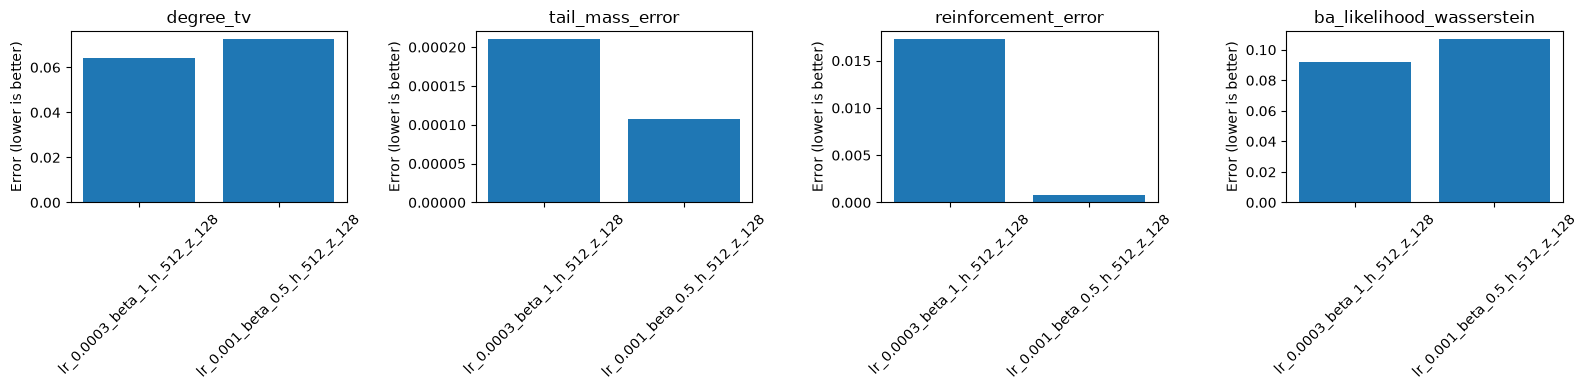

In [5]:
for stage_name, results in stage_results.items():
    print(f"\n{stage_name}")
    for result in results:
        pprint(
            {
                "candidate": result["candidate"],
                "promotion_score": result["promotion_score"],
                **result["spec"],
                **{metric: result[metric] for metric in RANK_METRICS},
            },
            sort_dicts=False,
        )

finalists = stage_results["stage_3"]
metrics_to_plot = ("degree_tv", "tail_mass_error", "reinforcement_error", "ba_likelihood_wasserstein")
figure, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))
names = [result["candidate"] for result in finalists]
for axis, metric in zip(axes, metrics_to_plot):
    axis.bar(names, [result[metric] for result in finalists])
    axis.set(title=metric, ylabel="Error (lower is better)")
    axis.tick_params(axis="x", rotation=45)
figure.tight_layout()
plt.show()


## Inspect finalist learning curves

The selected epoch is restored automatically, but the curves show whether a candidate converged cleanly or merely won at the stage's epoch limit.


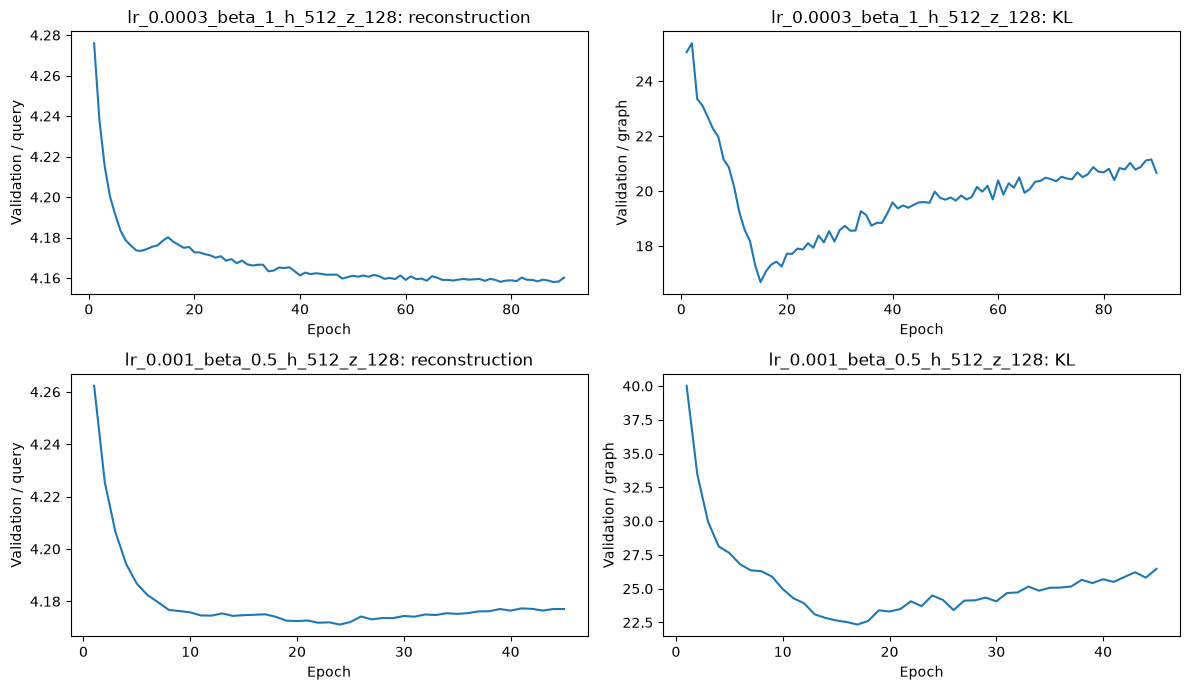

In [6]:
figure, axes = plt.subplots(len(finalists), 2, figsize=(12, 3.5 * len(finalists)), squeeze=False)
for row_axes, result in zip(axes, finalists):
    history = result["history"]
    epochs = [row["epoch"] for row in history]
    row_axes[0].plot(epochs, [row["val_recon_query"] for row in history])
    row_axes[0].set(title=f"{result['candidate']}: reconstruction", xlabel="Epoch", ylabel="Validation / query")
    row_axes[1].plot(epochs, [row["val_kl_graph"] for row in history])
    row_axes[1].set(title=f"{result['candidate']}: KL", xlabel="Epoch", ylabel="Validation / graph")
figure.tight_layout()
plt.show()


## Produce the full-scale configuration

This cell constructs, but does not train, a 262,144-graph configuration from the top-ranked finalist. Review the runner-up and the full evaluation metrics before starting the expensive final run.


Top finalist: lr_0.0003_beta_1_h_512_z_128
{'train': (262144, 256), 'validation': (8192, 256), 'test': (8192, 256)}


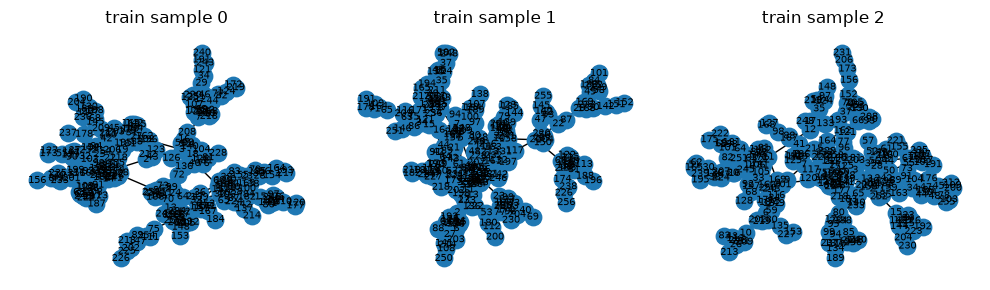

{'epoch': 1.0, 'beta': 0.05, 'train_recon_query': 4.249887665895026, 'train_kl_graph': 38.682454329034954, 'val_recon_query': 4.178478571373646, 'val_kl_graph': 61.298330545425415, 'early_stopping_bad_epochs': 0.0}
{'epoch': 2.0, 'beta': 0.1, 'train_recon_query': 4.158061699604425, 'train_kl_graph': 48.47447043284774, 'val_recon_query': 4.134729190135565, 'val_kl_graph': 51.17884659767151, 'early_stopping_bad_epochs': 0.0}
{'epoch': 3.0, 'beta': 0.15, 'train_recon_query': 4.126709476230651, 'train_kl_graph': 46.351400539278984, 'val_recon_query': 4.114808014997347, 'val_kl_graph': 48.327953815460205, 'early_stopping_bad_epochs': 0.0}
{'epoch': 4.0, 'beta': 0.2, 'train_recon_query': 4.110709058956837, 'train_kl_graph': 45.3415839523077, 'val_recon_query': 4.102516639889695, 'val_kl_graph': 46.90550458431244, 'early_stopping_bad_epochs': 0.0}
{'epoch': 5.0, 'beta': 0.25, 'train_recon_query': 4.099798727223254, 'train_kl_graph': 45.2090386711061, 'val_recon_query': 4.094439799391378, 'val

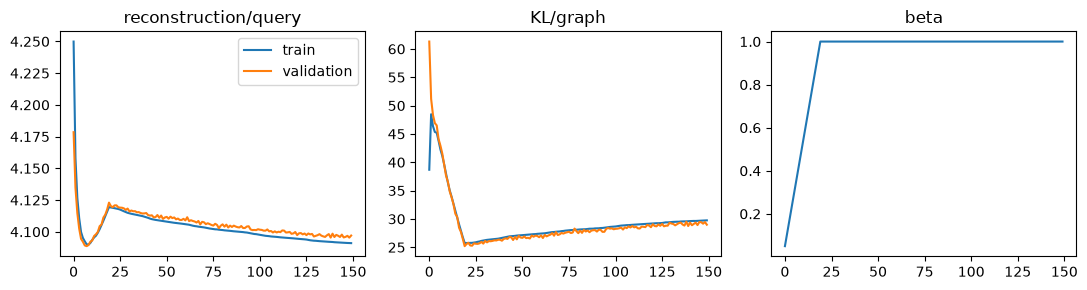

In [8]:
winner = finalists[0]
full_scale_config = replace(
    PROFILES["large"],
    profile="xlarge_256",
    train_graphs=262_144,
    val_graphs=8_192,
    test_graphs=8_192,
    generated_graphs=4_096,
    epochs=150,
    warmup_epochs=20,
    early_stopping_patience=12,
    **winner["spec"],
)

print("Top finalist:", winner["candidate"])
# full_scale_config
# Deliberately run the final training as a separate explicit command after review:
final_run = train(full_scale_config)
